In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.clean import clean_sales
from src.validate import validate_sales
from src.eda import summary_stats, missing_values

pd.set_option("display.max_columns", None)


In [5]:
df = pd.read_csv("data/sales_raw.csv")
df.head()


,date,product_id,product_name,sales,quantity,store_id
0,2023-01-01,101,Apple,120.5,10,1.0
1,2023/01/02,101,Apple,,8,1.0
2,2023-01-03,102,Banana,-50,5,1.0
3,2023-01-04,103,Orange,200,abc,2.0
4,2023-13-05,104,Grapes,300,12,2.0


In [6]:
df.info()
df.describe(include="all")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          10 non-null     object 
 1   product_id    10 non-null     int64  
 2   product_name  9 non-null      object 
 3   sales         9 non-null      object 
 4   quantity      10 non-null     object 
 5   store_id      9 non-null      float64
dtypes: float64(1), int64(1), object(4)
memory usage: 608.0+ bytes


,date,product_id,product_name,sales,quantity,store_id
count,10,10.000000,9,9,10,9.000000
unique,10,NaN,7,8,8,NaN
top,2023-01-01,NaN,Apple,120.5,10,NaN
freq,1,NaN,3,2,3,NaN
mean,NaN,103.800000,NaN,NaN,NaN,1.888889
std,NaN,2.616189,NaN,NaN,NaN,0.927961
min,NaN,101.000000,NaN,NaN,NaN,1.000000
25%,NaN,101.250000,NaN,NaN,NaN,1.000000
50%,NaN,103.500000,NaN,NaN,NaN,2.000000
75%,NaN,105.750000,NaN,NaN,NaN,3.000000


In [7]:
cleaned = clean_sales(df)
cleaned.head()


,date,product_id,product_name,sales,quantity,store_id
0,2023-01-01,101,Apple,120.5,10.0,1.0
8,2023-01-09,108,Kiwi,250.0,10.0,3.0
9,2023-01-10,101,Apple,120.5,10.0,1.0


In [8]:
validate_sales(cleaned)
print("Validation passed — cleaned dataset is valid.")
summary_stats(cleaned)
missing_values(cleaned)


Validation passed — cleaned dataset is valid.


date            0
product_id      0
product_name    0
sales           0
quantity        0
store_id        0
dtype: int64

In [9]:
cleaned.to_csv("data/sales_clean.csv", index=False)
print("Saved cleaned dataset to data/sales_clean.csv")


Saved cleaned dataset to data/sales_clean.csv


In [10]:
summary_stats(cleaned)


,date,product_id,product_name,sales,quantity,store_id
count,3,3.000000,3,3.000000,3.0,3.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,Apple,NaN,NaN,NaN
freq,NaN,NaN,2,NaN,NaN,NaN
mean,2023-01-06 16:00:00,103.333333,NaN,163.666667,10.0,1.666667
min,2023-01-01 00:00:00,101.000000,NaN,120.500000,10.0,1.000000
25%,2023-01-05 00:00:00,101.000000,NaN,120.500000,10.0,1.000000
50%,2023-01-09 00:00:00,101.000000,NaN,120.500000,10.0,1.000000
75%,2023-01-09 12:00:00,104.500000,NaN,185.250000,10.0,2.000000
max,2023-01-10 00:00:00,108.000000,NaN,250.000000,10.0,3.000000


In [11]:
missing_values(cleaned)


date            0
product_id      0
product_name    0
sales           0
quantity        0
store_id        0
dtype: int64

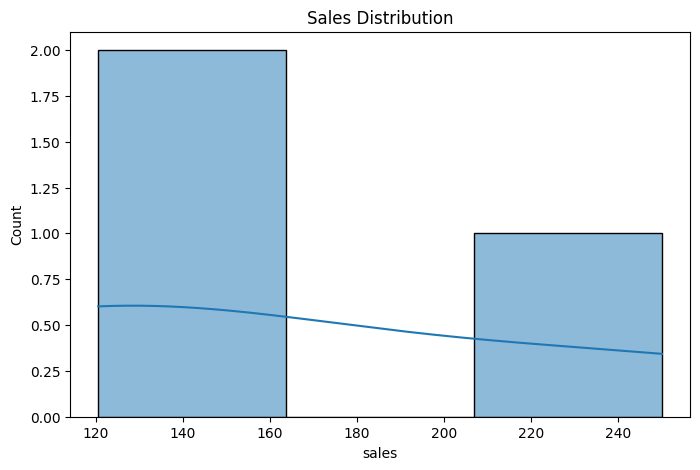

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(cleaned["sales"], kde=True)
plt.title("Sales Distribution")
plt.show()


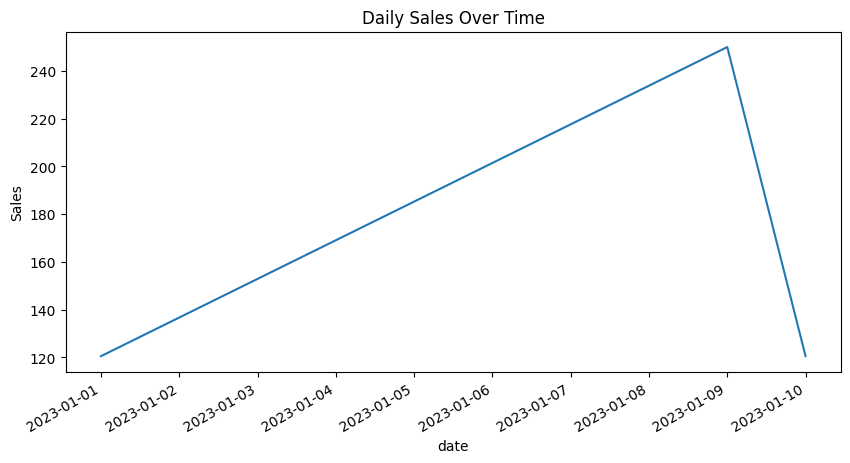

In [14]:
if "date" in cleaned.columns:
    cleaned["date"] = pd.to_datetime(cleaned["date"])
    cleaned.groupby("date")["sales"].sum().plot(figsize=(10,5))
    plt.title("Daily Sales Over Time")
    plt.ylabel("Sales")
    plt.show()


In [17]:
if "product" in cleaned.columns:
    cleaned.groupby("product")["sales"].sum().sort_values().plot(kind="bar", figsize=(10,5))
    plt.title("Sales by Product")
    plt.ylabel("Total Sales")
    plt.show()


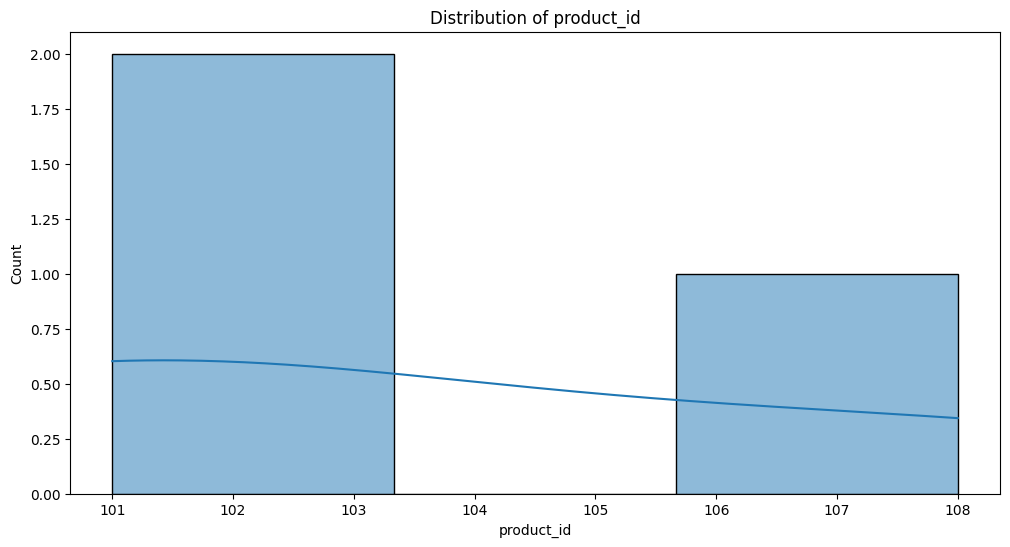

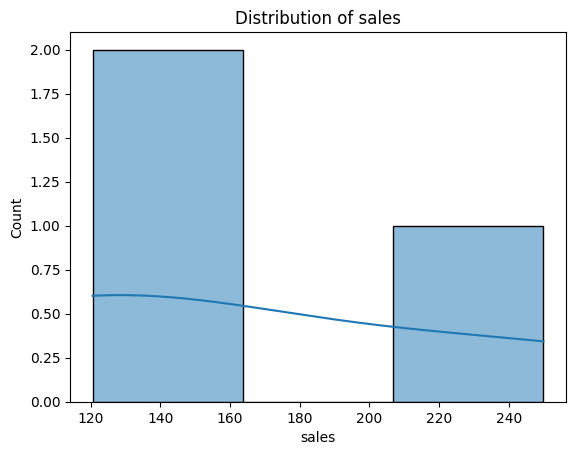

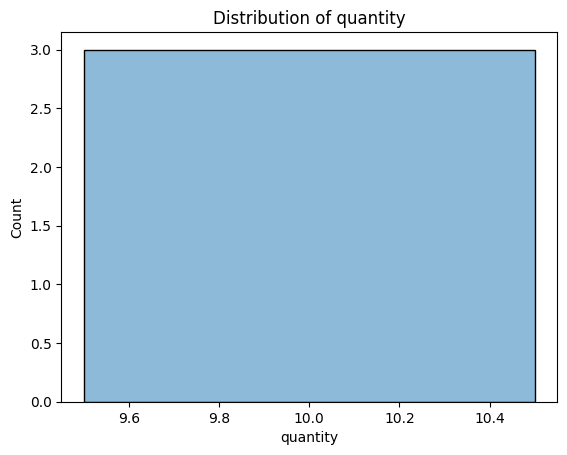

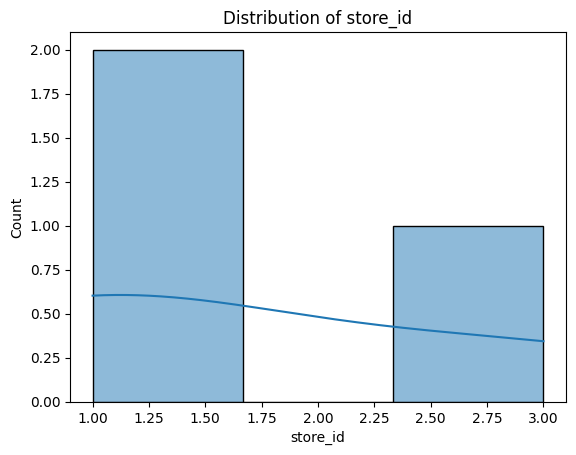

In [19]:
numeric_cols = cleaned.select_dtypes(include="number").columns

plt.figure(figsize=(12, 6))
for col in numeric_cols:
    sns.histplot(cleaned[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


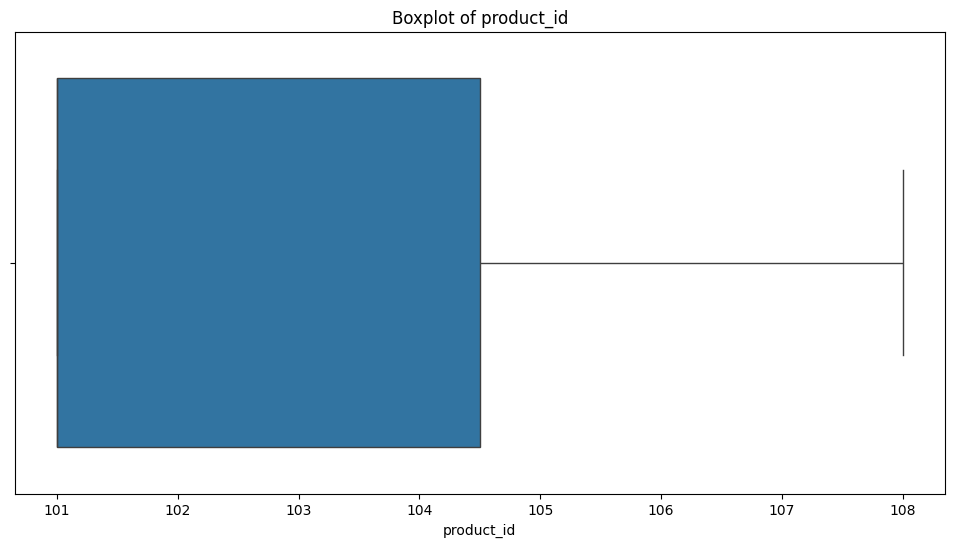

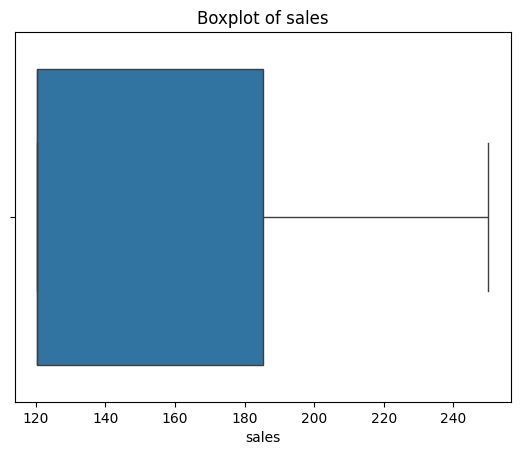

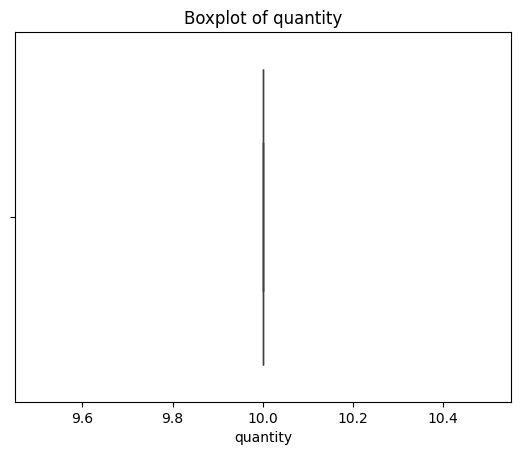

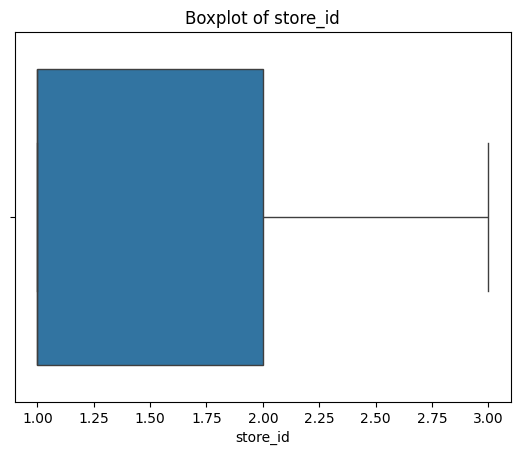

In [21]:
plt.figure(figsize=(12, 6))
for col in numeric_cols:
    sns.boxplot(x=cleaned[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


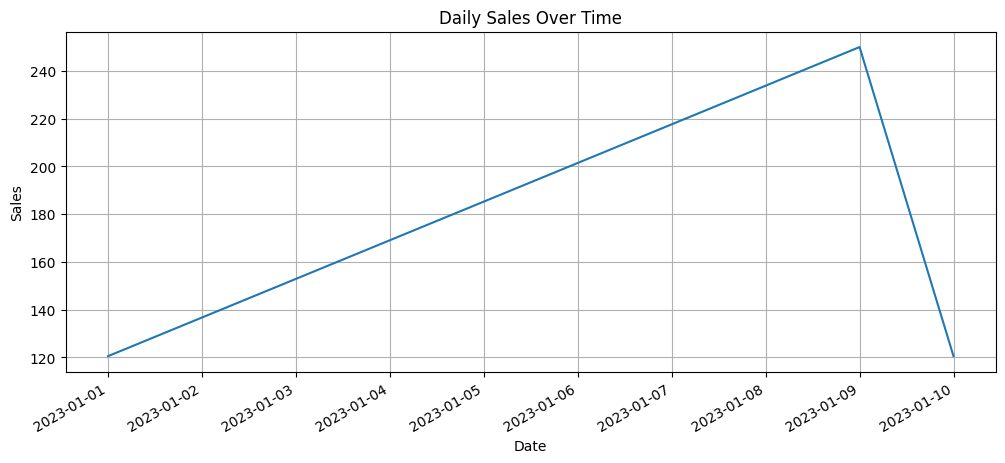

In [22]:
if "date" in cleaned.columns:
    cleaned["date"] = pd.to_datetime(cleaned["date"])
    daily = cleaned.groupby("date")["sales"].sum()

    plt.figure(figsize=(12, 5))
    daily.plot()
    plt.title("Daily Sales Over Time")
    plt.ylabel("Sales")
    plt.xlabel("Date")
    plt.grid(True)
    plt.show()
